<h1>AST326Y1 Practical 1 - Activity 4.1</h1>

Let's begin by importing all the required libraries:

In [2]:
import numpy as np
from scipy.special import factorial
import matplotlib.pyplot as plt

<h2>Part 1: Table sample set</h2> <br>
This sample set needs to be hardcoded since there is no file to read from. The goal is to recreate a figure similar to <em>Figure 7</em> in the handout.

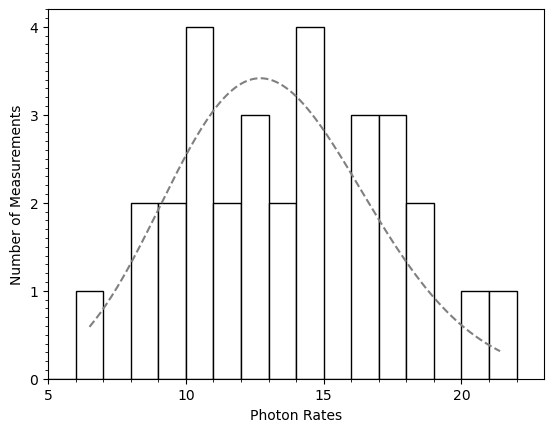

In [3]:
"""
Part 1: Small sample set
This part uses data from the table in section 4.1 of the lab handout to 
recreate figure 7.
"""
p1_spl = [13, 17, 18, 14, 11, 8, 21, 18, 9, 12,
          9, 17, 14, 6, 10, 16, 16, 11, 10, 12,
          8, 20, 14, 10, 14, 17, 13, 16, 12, 10]
    
p1_stdev = np.std(p1_spl)
p1_mean = np.mean(p1_spl)

ax = plt.axes()
plt.hist(p1_spl, bins=17, range=(5,22), edgecolor="black", color="white")
plt.xlim(5, 23)

ax.set_yticks(np.arange(0, 5, 1))
ax.set_xticks(np.arange(5, 25, 5))

ax.set_yticks(np.arange(0, 4.6, 0.1), minor=True)
ax.set_xticks(np.arange(5, 23, 1), minor=True)

plt.xlabel('Photon Rates')
plt.ylabel('Number of Measurements')

# Poisson distribution overplot
x = np.arange(6.5, 21.5, 0.1)
y = np.exp(-p1_mean) * np.power(p1_mean, x)/factorial(x)

amp = 31 # amplify the presence of the Poisson distribution
ax.plot(x, y * amp, color="gray", linestyle="dashed")

<h2>Part 2: Loading data from files (<code>small.txt</code>, <code>large.txt</code>)</h2> <br>
Now, larger data sets can be found in files `small.txt` and `large.txt`. <br>
The goal is to: <br>
1. Read the data, <br>
2. Calculate their mean and standard deviation and assess these values: are they similar to a Poisson distribution? <br>
3. Show the data in two histograms. <br>
4. Overplot a Poisson and Gaussian distribution over each of them. Which one fits best? <br>

In [4]:
"""
Part 2: Loading data from files
This part uses data from files located in ../src, and finds mean and 
standard deviation values for both files.
The data is also used to plot the distributions of both files, to compare 
them to common distributions.
"""
x1 = np.arange(0, 13, 0.1)
x2 = np.arange(950, 1200, 2)

p2_small = np.loadtxt('Small.txt')
p2_large = np.loadtxt('Large.txt')

small_mean = np.mean(p2_small)
small_std = np.std(p2_small)

large_mean = np.mean(p2_large)
large_std = np.std(p2_large)

print('Small mean:', small_mean, ', Small StDev:', small_std)
print('Large mean:', large_mean, ', Large StDev:', large_std)

Small mean: 3.392 , Small StDev: 1.8580462857528603
Large mean: 1072.528 , Large StDev: 32.8154722044343


Notice that the small sample set has $\sigma_{\text{small}} \approx (\mu_{\text{small}})^\frac{1}{2}$, a strong hint toward it following a Poisson distribution (which has $\sigma = \mu^\frac{1}{2}$). <br> 
The large sample set has a very low standard deviation relative to the mean, which means that the distribution is likely very symmetric around the mean. This is expected as well, since the mean is very high (multiple powers of 10) meaning that the Poisson distribution tends towards a normal distribution. <br>

Now, for showing histograms of the data, we will begin by making helper functions for the Poisson and Gaussian distributions. The Gaussian method is here for ease of use, and the Poisson method is used to avoid issues with overflow with factorials of very large numbers in `large.txt`. <br>

In [5]:
def pois(x_arr, mu):
    """
    Return Poisson distribution using integer array x_arr and mean mu.
    Used to counteract scipy.special.factorial() overflow for p2_large.
    """
    result = np.exp(-mu, dtype=np.float128) \
            * np.power(mu, x_arr, dtype=np.float128)
    
    # division by factorial, implemented by integer 
    for i in range(0, len(result) - 1):
        for j in range(1, x_arr[i] + 1):
            result[i] /= j
    return result

def gauss(x_arr, mu, sd):
    """
    Return Gaussian distribution of x_arr with mean mu and standard 
    deviation sd.
    """
    return np.exp(-0.5 * ((x_arr - mu)/sd)**2)/(sd * (2*np.pi)**0.5)

Then, we can start making the figure! <br>

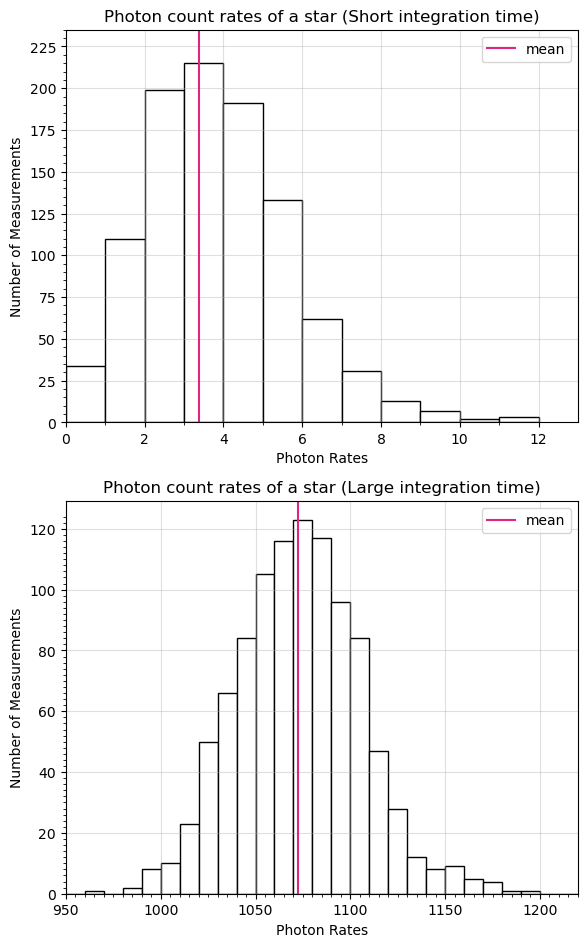

In [12]:
fig, axs = plt.subplots(2, 1)

plt.subplots_adjust(bottom=0, left=0.2, right=1, top=1.8, hspace=0.2)

axs[0].hist(p2_small, bins=12, edgecolor='black', color='white')
axs[1].hist(p2_large, bins=np.arange(950, 1230, 10), edgecolor='black', color='white')

axs[0].axvline(small_mean, color='#DC267F', label='mean')
axs[1].axvline(large_mean, color='#DC267F', label='mean')

axs[0].set_xlim(0, 13)
axs[0].set_xticks(np.arange(0, 13, 2))
axs[0].set_xticks(np.arange(0, 13, 1), minor=True)
axs[0].set_yticks(np.arange(0, 250, 25))
axs[0].set_yticks(np.arange(0, 240, 5), minor=True)

axs[1].set_xlim(950, 1200)
axs[1].set_xticks(np.arange(950, 1250, 50))
axs[1].set_xticks(np.arange(950, 1225, 5), minor=True)
axs[1].set_yticks(np.arange(0, 140, 20))
axs[1].set_yticks(np.arange(0, 125, 2), minor=True)

axs[0].set_xlabel('Photon Rates')
axs[0].set_ylabel('Number of Measurements')
axs[0].set_title('Photon count rates of a star (Short integration time)')
axs[0].grid(visible=True, alpha=0.4)
axs[0].legend()

axs[1].set_xlabel('Photon Rates')
axs[1].set_ylabel('Number of Measurements')
axs[1].set_title('Photon count rates of a star (Large integration time)')
axs[1].grid(visible=True, alpha=0.4)
axs[1].legend()

Before overplotting the Poisson and Gaussian distributions, the sample set from `small.txt` seems to be skewed as expected, which makes it appear to be following the Poisson distribution we were deducing. <br>
The set from `large.txt` however seems much more symmetric around its mean of approximately 1070, indicating a normal distribution as expected too.

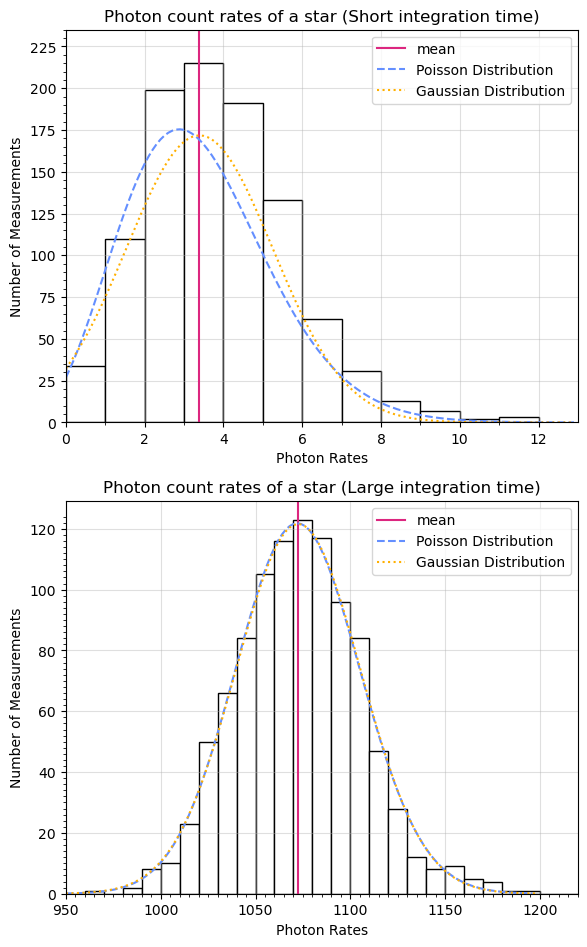

In [14]:
fig, axs = plt.subplots(2, 1)

plt.subplots_adjust(bottom=0, left=0.2, right=1, top=1.8, hspace=0.2)

axs[0].hist(p2_small, bins=12, edgecolor='black', color='white')
axs[1].hist(p2_large, bins=np.arange(950, 1230, 10), edgecolor='black', color='white')

axs[0].axvline(small_mean, color='#DC267F', label='mean')
axs[1].axvline(large_mean, color='#DC267F', label='mean')

# Poisson distribution overplot
pois_small = np.exp(-small_mean) * np.power(small_mean, x1)/factorial(x1)
pois_large = pois(x2, large_mean)

# amplifier values to make Poisson curves more visible
amp1 = 800
amp2 = 10000

axs[0].plot(x1, pois_small * amp1, color='#648FFF', linestyle='dashed', 
            label='Poisson Distribution')

axs[1].plot(x2, pois_large * amp2, color='#648FFF', linestyle='dashed', 
            label='Poisson Distribution')

# Gaussian distribution overplot
gauss_small = gauss(x1, small_mean, small_std)
gauss_large = gauss(x2, large_mean, large_std)

axs[0].plot(x1, gauss_small * amp1, color='#FFB000', linestyle='dotted', 
            label='Gaussian Distribution')

axs[1].plot(x2, gauss_large * amp2, color='#FFB000', linestyle='dotted', 
            label='Gaussian Distribution')

axs[0].set_xlim(0, 13)
axs[0].set_xticks(np.arange(0, 13, 2))
axs[0].set_xticks(np.arange(0, 13, 1), minor=True)
axs[0].set_yticks(np.arange(0, 250, 25))
axs[0].set_yticks(np.arange(0, 240, 5), minor=True)

axs[1].set_xlim(950, 1220)
axs[1].set_xticks(np.arange(950, 1250, 50))
axs[1].set_xticks(np.arange(950, 1225, 5), minor=True)
axs[1].set_yticks(np.arange(0, 140, 20))
axs[1].set_yticks(np.arange(0, 125, 2), minor=True)

axs[0].set_xlabel('Photon Rates')
axs[0].set_ylabel('Number of Measurements')
axs[0].set_title('Photon count rates of a star (Short integration time)')
axs[0].grid(visible=True, alpha=0.4)
axs[0].legend()

axs[1].set_xlabel('Photon Rates')
axs[1].set_ylabel('Number of Measurements')
axs[1].set_title('Photon count rates of a star (Large integration time)')
axs[1].grid(visible=True, alpha=0.4)
axs[1].legend()

On the histogram of `small.txt` data, it seems that the Poisson distribution fits best, as it best represents the skew visible in the data. <br>
For the histogram of `large.txt` however, the overplots are more interesting: the Poisson and Gaussian distributions seem to nearly overlap, which is because a Poisson distribution tends to a normal distribution as $\mu \to \infty$. So, in this latter case, either the Poisson or Gaussian distribution are a good fit (although a Gaussian is most likely better in the code sense since it causes less overflow issues!)